In [ ]:
import torch
import timm
import time
from datasets import load_dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
# --- Configuration ---
# Using the exact pattern for your files
DATA_FILES = "./data/validation-*.parquet" 
BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_dataloader():
    print(f"Loading parquet dataset from {DATA_FILES}...")
    
    # Load all local parquet files into a single Map-style dataset
    dataset = load_dataset("parquet", data_files=DATA_FILES, split="train")
    
    # Verification: ImageNet validation set must be exactly 50,000 images
    print(f"Total images loaded: {len(dataset)}")
    if len(dataset) != 50000:
        print("WARNING: Dataset length is not 50,000! Check your parquet files.")

    # Standard ImageNet validation transforms
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    def preprocess(examples):
        # Convert to RGB and apply transform
        images = [val_transform(img.convert('RGB')) for img in examples['image']]
        # Explicitly return PyTorch tensors to prevent DataLoader crashes
        return {
            'image': images,
            'label': examples['label']
        }

    # Apply transforms on the fly
    dataset = dataset.with_transform(preprocess)
    
    # Create the PyTorch DataLoader
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
    return dataloader

def evaluate_model(model, dataloader, model_name):
    print(f"\n{'='*50}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*50}")
    
    model.eval()
    correct = 0
    total = 0
    timings = []
    
    # Use accurate CUDA timing if available, otherwise fallback to CPU time
    use_cuda_timing = DEVICE.type == 'cuda'
    if use_cuda_timing:
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)
    
    # Calculate parameter count (in Millions)
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {params / 1e6:.2f} M")

    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="Inference")):
            inputs = batch['image'].to(DEVICE)
            targets = batch['label'].to(DEVICE)

            # --- Timing Start ---
            if i > 5: # Warmup for the first 5 batches
                if use_cuda_timing:
                    starter.record()
                else:
                    start_time = time.time()
                    
            outputs = model(inputs)
            
            # --- Timing End ---
            if i > 5:
                if use_cuda_timing:
                    ender.record()
                    torch.cuda.synchronize()
                    timings.append(starter.elapsed_time(ender))
                else:
                    end_time = time.time()
                    timings.append((end_time - start_time) * 1000) # Convert to ms

            # Calculate accuracy
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    # Calculate final metrics
    top1_acc = 100. * correct / total
    
    # Avoid division by zero if dataset is too small for warmup
    avg_latency_ms = sum(timings) / len(timings) if timings else 0 
    throughput = (BATCH_SIZE / avg_latency_ms) * 1000 if avg_latency_ms > 0 else 0
    
    print(f"\n--- Final Results for {model_name} ---")
    print(f"Top-1 Accuracy: {top1_acc:.2f}%")
    print(f"Avg Batch Latency: {avg_latency_ms:.2f} ms")
    print(f"Throughput: {throughput:.2f} images/sec")
    
    return top1_acc, throughput

def main():
    if not torch.cuda.is_available():
        print("\nWARNING: CUDA is not available. Running on CPU. Latency will be slow and not reflective of production.\n")
        
    dataloader = get_dataloader()

    # Define the models required for Direction 2[cite: 18].
    models_to_test = {
        "Standard ViT (Small)": timm.create_model('vit_small_patch16_224', pretrained=True).to(DEVICE),
        "EfficientFormer (L1)": timm.create_model('efficientformer_l1', pretrained=True).to(DEVICE),
        "EfficientViT (M4)": timm.create_model('efficientvit_m4', pretrained=True).to(DEVICE) 
    }

    # Run the evaluation loop for each model
    for name, model in models_to_test.items():
        evaluate_model(model, dataloader, name)

if __name__ == "__main__":
    main()

Loading parquet dataset from ./data/validation-*.parquet...
Total images loaded: 50000

Evaluating: Standard ViT (Small)
Parameters: 22.05 M


Inference: 100%|██████████| 782/782 [01:40<00:00,  7.76it/s]



--- Final Results for Standard ViT (Small) ---
Top-1 Accuracy: 74.63%
Avg Batch Latency: 122.67 ms
Throughput: 521.72 images/sec

Evaluating: EfficientFormer (L1)
Parameters: 12.29 M


Inference: 100%|██████████| 782/782 [01:14<00:00, 10.54it/s]



--- Final Results for EfficientFormer (L1) ---
Top-1 Accuracy: 80.18%
Avg Batch Latency: 52.89 ms
Throughput: 1210.07 images/sec

Evaluating: EfficientViT (M4)
Parameters: 8.80 M


Inference: 100%|██████████| 782/782 [01:04<00:00, 12.05it/s]


--- Final Results for EfficientViT (M4) ---
Top-1 Accuracy: 74.15%
Avg Batch Latency: 22.40 ms
Throughput: 2856.59 images/sec


Graph successfully saved as 'baseline_pareto_curve.png' in your current directory.


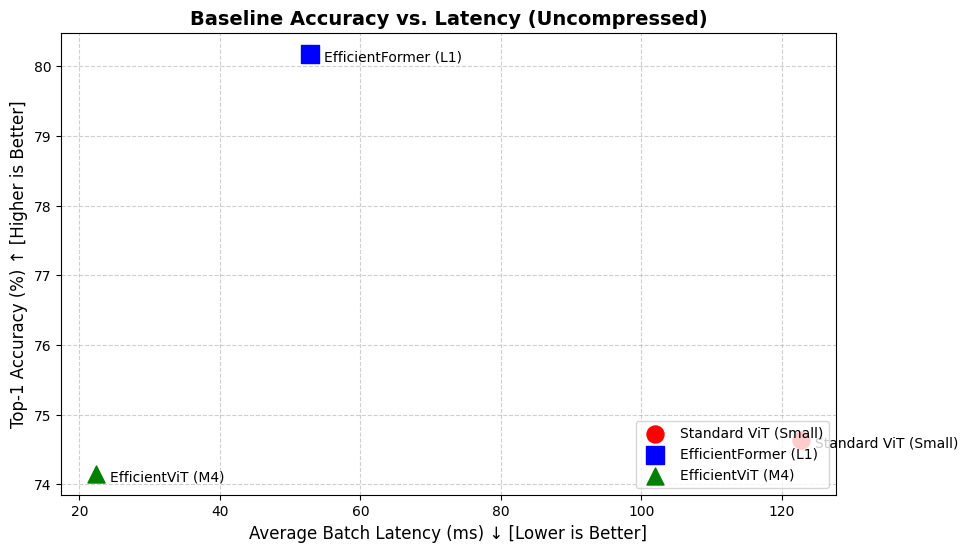

In [6]:
import matplotlib.pyplot as plt
def plot_baseline_pareto():
    """
    Plots the initial Accuracy vs. Latency baseline points for Direction 2.
    Replace the placeholder values below with your actual terminal outputs.
    """
    # --- 1. Plug in your actual results here ---
    # Format: {"Model Name": Value}
    accuracies = {
        "Standard ViT (Small)": 74.63,   # Replace with your actual Top-1 Acc
        "EfficientFormer (L1)": 80.18,   # Replace with your actual Top-1 Acc
        "EfficientViT (M4)": 74.15       # Replace with your actual Top-1 Acc
    }
    
    latencies_ms = {
        "Standard ViT (Small)": 122.67,   # Replace with your avg batch latency (ms)
        "EfficientFormer (L1)": 52.89,    # Replace with your avg batch latency (ms)
        "EfficientViT (M4)": 22.40        # Replace with your avg batch latency (ms)
    }

    # Colors and markers for visual distinction
    styles = {
        "Standard ViT (Small)": {"color": "red", "marker": "o"},
        "EfficientFormer (L1)": {"color": "blue", "marker": "s"},
        "EfficientViT (M4)": {"color": "green", "marker": "^"}
    }

    # --- 2. Create the Plot ---
    plt.figure(figsize=(10, 6))
    
    for model_name in accuracies.keys():
        plt.scatter(
            latencies_ms[model_name], 
            accuracies[model_name], 
            label=model_name,
            color=styles[model_name]["color"],
            marker=styles[model_name]["marker"],
            s=150, # Marker size
            zorder=5
        )
        
        # Add text labels slightly offset from the points
        plt.annotate(
            model_name,
            (latencies_ms[model_name], accuracies[model_name]),
            xytext=(10, -5), 
            textcoords='offset points',
            fontsize=10
        )

    # --- 3. Formatting ---
    plt.title("Baseline Accuracy vs. Latency (Uncompressed)", fontsize=14, fontweight='bold')
    plt.xlabel("Average Batch Latency (ms) ↓ [Lower is Better]", fontsize=12)
    plt.ylabel("Top-1 Accuracy (%) ↑ [Higher is Better]", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc="lower right")
    
    # Invert X-axis if you want the "best" models (lowest latency, highest accuracy) 
    # to appear in the top-right corner, which is standard for Pareto frontiers.
    # plt.gca().invert_xaxis() 

    # --- 4. Save the Graph ---
    output_filename = "baseline_pareto_curve.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Graph successfully saved as '{output_filename}' in your current directory.")
    
    plt.show() # Uncomment if you are running this in a Jupyter notebook or GUI

if __name__ == "__main__":
    plot_baseline_pareto()